In [1]:
#importing libraries

import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader

In [2]:
# set device and create necessary directories
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

os.makedirs("../models", exist_ok=True)
os.makedirs("../results", exist_ok=True)

Using: cpu


In [3]:
# define paths and hyperparameters
TRAIN_PATH = "../data/DATASET/train"
TEST_PATH = "../data/DATASET/test"

IMG_SIZE = 224
BATCH_SIZE = 64
NUM_CLASSES = 7
EPOCHS = 50

In [4]:
# define image transformations
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.1)),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [5]:
# loading datasets 
train_dataset = datasets.ImageFolder(TRAIN_PATH, transform=train_transform)
test_dataset = datasets.ImageFolder(TEST_PATH, transform=test_transform)

print("Train images:", len(train_dataset))
print("Test images:", len(test_dataset))
print("Classes:", train_dataset.classes)
print("Class to index:", train_dataset.class_to_idx)

Train images: 12271
Test images: 3068
Classes: ['1', '2', '3', '4', '5', '6', '7']
Class to index: {'1': 0, '2': 1, '3': 2, '4': 3, '5': 4, '6': 5, '7': 6}


In [6]:
# data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 192
Validation batches: 48


In [7]:
# compute class weights for imbalanced dataset
targets = np.array(train_dataset.targets)
unique, counts = np.unique(targets, return_counts=True)

class_weights = 1.0 / torch.tensor(counts, dtype=torch.float)
class_weights = class_weights / class_weights.sum() * len(unique)
class_weights = class_weights.to(device)

print("Class counts:", dict(zip(unique, counts)))
print("Class weights:", class_weights)

Class counts: {np.int64(0): np.int64(1290), np.int64(1): np.int64(281), np.int64(2): np.int64(717), np.int64(3): np.int64(4772), np.int64(4): np.int64(1982), np.int64(5): np.int64(705), np.int64(6): np.int64(2524)}
Class weights: tensor([0.6572, 3.0168, 1.1823, 0.1776, 0.4277, 1.2025, 0.3359])


In [8]:
# load pretrained ResNet34 and modify final layer
model = models.resnet34(pretrained=True)

model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, NUM_CLASSES)
)

model = model.to(device)

C:\Users\kusha\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\kusha\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [9]:
# freeze all layers except the last two blocks and the fully connected layer
for param in model.parameters():
    param.requires_grad = False

for param in model.layer3.parameters():
    param.requires_grad = True

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

In [10]:
# define loss function, optimizer, and learning rate scheduler

best_val_acc = 0
patience = 7
patience_counter = 0

history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "val_acc": []
}

model_save_path = "../models/emotion_resnet34_transfer.pth"
history_save_path = "../results/emotion_resnet34_transfer_history.csv"
curve_save_path = "../results/emotion_resnet34_transfer_curve.png"

loss_fn = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1
)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-6
)

In [11]:
# training loop with early stopping

for epoch in range(EPOCHS):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for i, (batch_X, batch_y) in enumerate(train_loader):
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        preds = model(batch_X)
        loss = loss_fn(preds, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_X.size(0)

        _, predicted = torch.max(preds, 1)
        correct += (predicted == batch_y).sum().item()
        total += batch_y.size(0)

        if i % 50 == 0:
            print(f"Epoch {epoch+1} | Batch {i}/{len(train_loader)} | Loss: {loss.item():.4f}")

    train_loss = total_loss / len(train_loader.dataset)
    train_acc = correct / total

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            preds = model(batch_X)
            _, predicted = torch.max(preds, 1)

            correct += (predicted == batch_y).sum().item()
            total += batch_y.size(0)

    val_acc = correct / total

    history["epoch"].append(epoch + 1)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch+1}, "
        f"Loss: {train_loss:.3f}, "
        f"Train Acc: {train_acc:.3f}, "
        f"Val Acc: {val_acc:.3f}"
    )

    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), model_save_path)
        print(f"New best transfer learning model saved! Val Acc: {val_acc:.3f}")
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

print(f"Best transfer learning validation accuracy: {best_val_acc:.3f}")

Epoch 1 | Batch 0/192 | Loss: 3.0094
Epoch 1 | Batch 50/192 | Loss: 2.0242
Epoch 1 | Batch 100/192 | Loss: 1.9207
Epoch 1 | Batch 150/192 | Loss: 1.6239
Epoch 1, Loss: 1.901, Train Acc: 0.402, Val Acc: 0.612
New best transfer learning model saved! Val Acc: 0.612
Epoch 2 | Batch 0/192 | Loss: 2.1149
Epoch 2 | Batch 50/192 | Loss: 1.5326
Epoch 2 | Batch 100/192 | Loss: 1.7128
Epoch 2 | Batch 150/192 | Loss: 1.5090
Epoch 2, Loss: 1.603, Train Acc: 0.588, Val Acc: 0.624
New best transfer learning model saved! Val Acc: 0.624
Epoch 3 | Batch 0/192 | Loss: 1.4950
Epoch 3 | Batch 50/192 | Loss: 1.4582
Epoch 3 | Batch 100/192 | Loss: 1.2072
Epoch 3 | Batch 150/192 | Loss: 1.6956
Epoch 3, Loss: 1.485, Train Acc: 0.654, Val Acc: 0.768
New best transfer learning model saved! Val Acc: 0.768
Epoch 4 | Batch 0/192 | Loss: 1.2252
Epoch 4 | Batch 50/192 | Loss: 1.6117
Epoch 4 | Batch 100/192 | Loss: 1.4245
Epoch 4 | Batch 150/192 | Loss: 1.5236
Epoch 4, Loss: 1.426, Train Acc: 0.690, Val Acc: 0.668
Epo

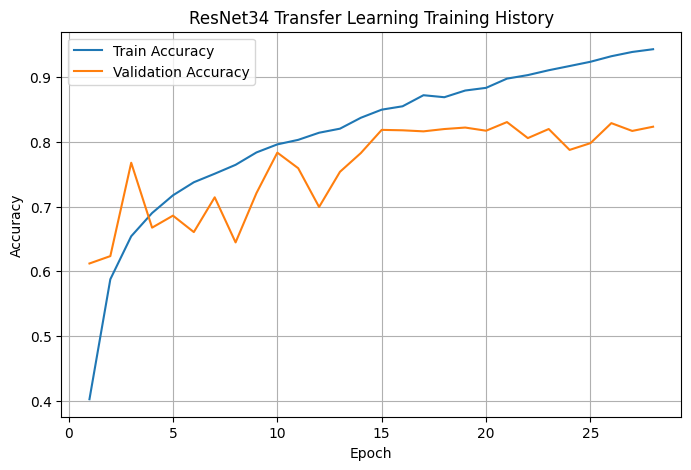

Model saved to: ../models/emotion_resnet34_transfer.pth
History saved to: ../results/emotion_resnet34_transfer_history.csv
Curve saved to: ../results/emotion_resnet34_transfer_curve.png


In [12]:
# save training history and plot curves

history_df = pd.DataFrame(history)
history_df.to_csv(history_save_path, index=False)

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_acc"], label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet34 Transfer Learning Training History")
plt.legend()
plt.grid(True)
plt.savefig(curve_save_path, bbox_inches="tight")
plt.show()

print("Model saved to:", model_save_path)
print("History saved to:", history_save_path)
print("Curve saved to:", curve_save_path)